<a href="https://colab.research.google.com/github/Raka7317/DATA-STRUCTURE-/blob/main/waste_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Using device: cuda
📥 Downloading TrashNet dataset...
✅ Dataset downloaded and extracted!
✅ Dataset: 2527 images | 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
   Train: 1768 | Val: 379 | Test: 380
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]



🚀 Starting Training...

Epoch [01/30] | Loss: 83.8485 | Train: 45.64% | Val: 68.87% | LR: 0.000100
   🏆 Best model saved! Val Acc: 68.87%
Epoch [02/30] | Loss: 60.8972 | Train: 68.72% | Val: 81.79% | LR: 0.000099
   🏆 Best model saved! Val Acc: 81.79%
Epoch [03/30] | Loss: 52.3048 | Train: 77.83% | Val: 85.49% | LR: 0.000098
   🏆 Best model saved! Val Acc: 85.49%
Epoch [04/30] | Loss: 48.0216 | Train: 80.20% | Val: 87.60% | LR: 0.000096
   🏆 Best model saved! Val Acc: 87.60%
Epoch [05/30] | Loss: 45.8231 | Train: 82.41% | Val: 86.54% | LR: 0.000093
Epoch [06/30] | Loss: 43.3173 | Train: 85.07% | Val: 89.45% | LR: 0.000091
   🏆 Best model saved! Val Acc: 89.45%
Epoch [07/30] | Loss: 42.1507 | Train: 86.03% | Val: 90.50% | LR: 0.000087
   🏆 Best model saved! Val Acc: 90.50%
Epoch [08/30] | Loss: 40.7785 | Train: 86.65% | Val: 90.24% | LR: 0.000084
Epoch [09/30] | Loss: 39.3139 | Train: 88.07% | Val: 89.97% | LR: 0.000080
Epoch [10/30] | Loss: 37.6664 | Train: 89.82% | Val: 89.71% | LR: 

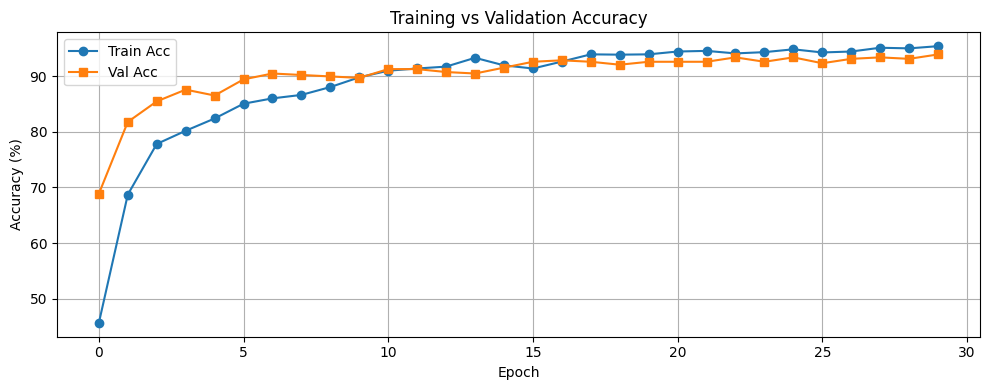


📊 Evaluating on Test Set...

Accuracy:  0.9474
Precision: 0.9497
Recall:    0.9474
F1 Score:  0.9464

📋 Per-Class Report:
              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        59
       glass       0.94      0.97      0.96        78
       metal       0.91      1.00      0.95        61
       paper       0.93      1.00      0.96        92
     plastic       0.98      0.83      0.90        66
       trash       0.95      0.83      0.89        24

    accuracy                           0.95       380
   macro avg       0.95      0.93      0.94       380
weighted avg       0.95      0.95      0.95       380


🔍 Running Grad-CAM Explanations...



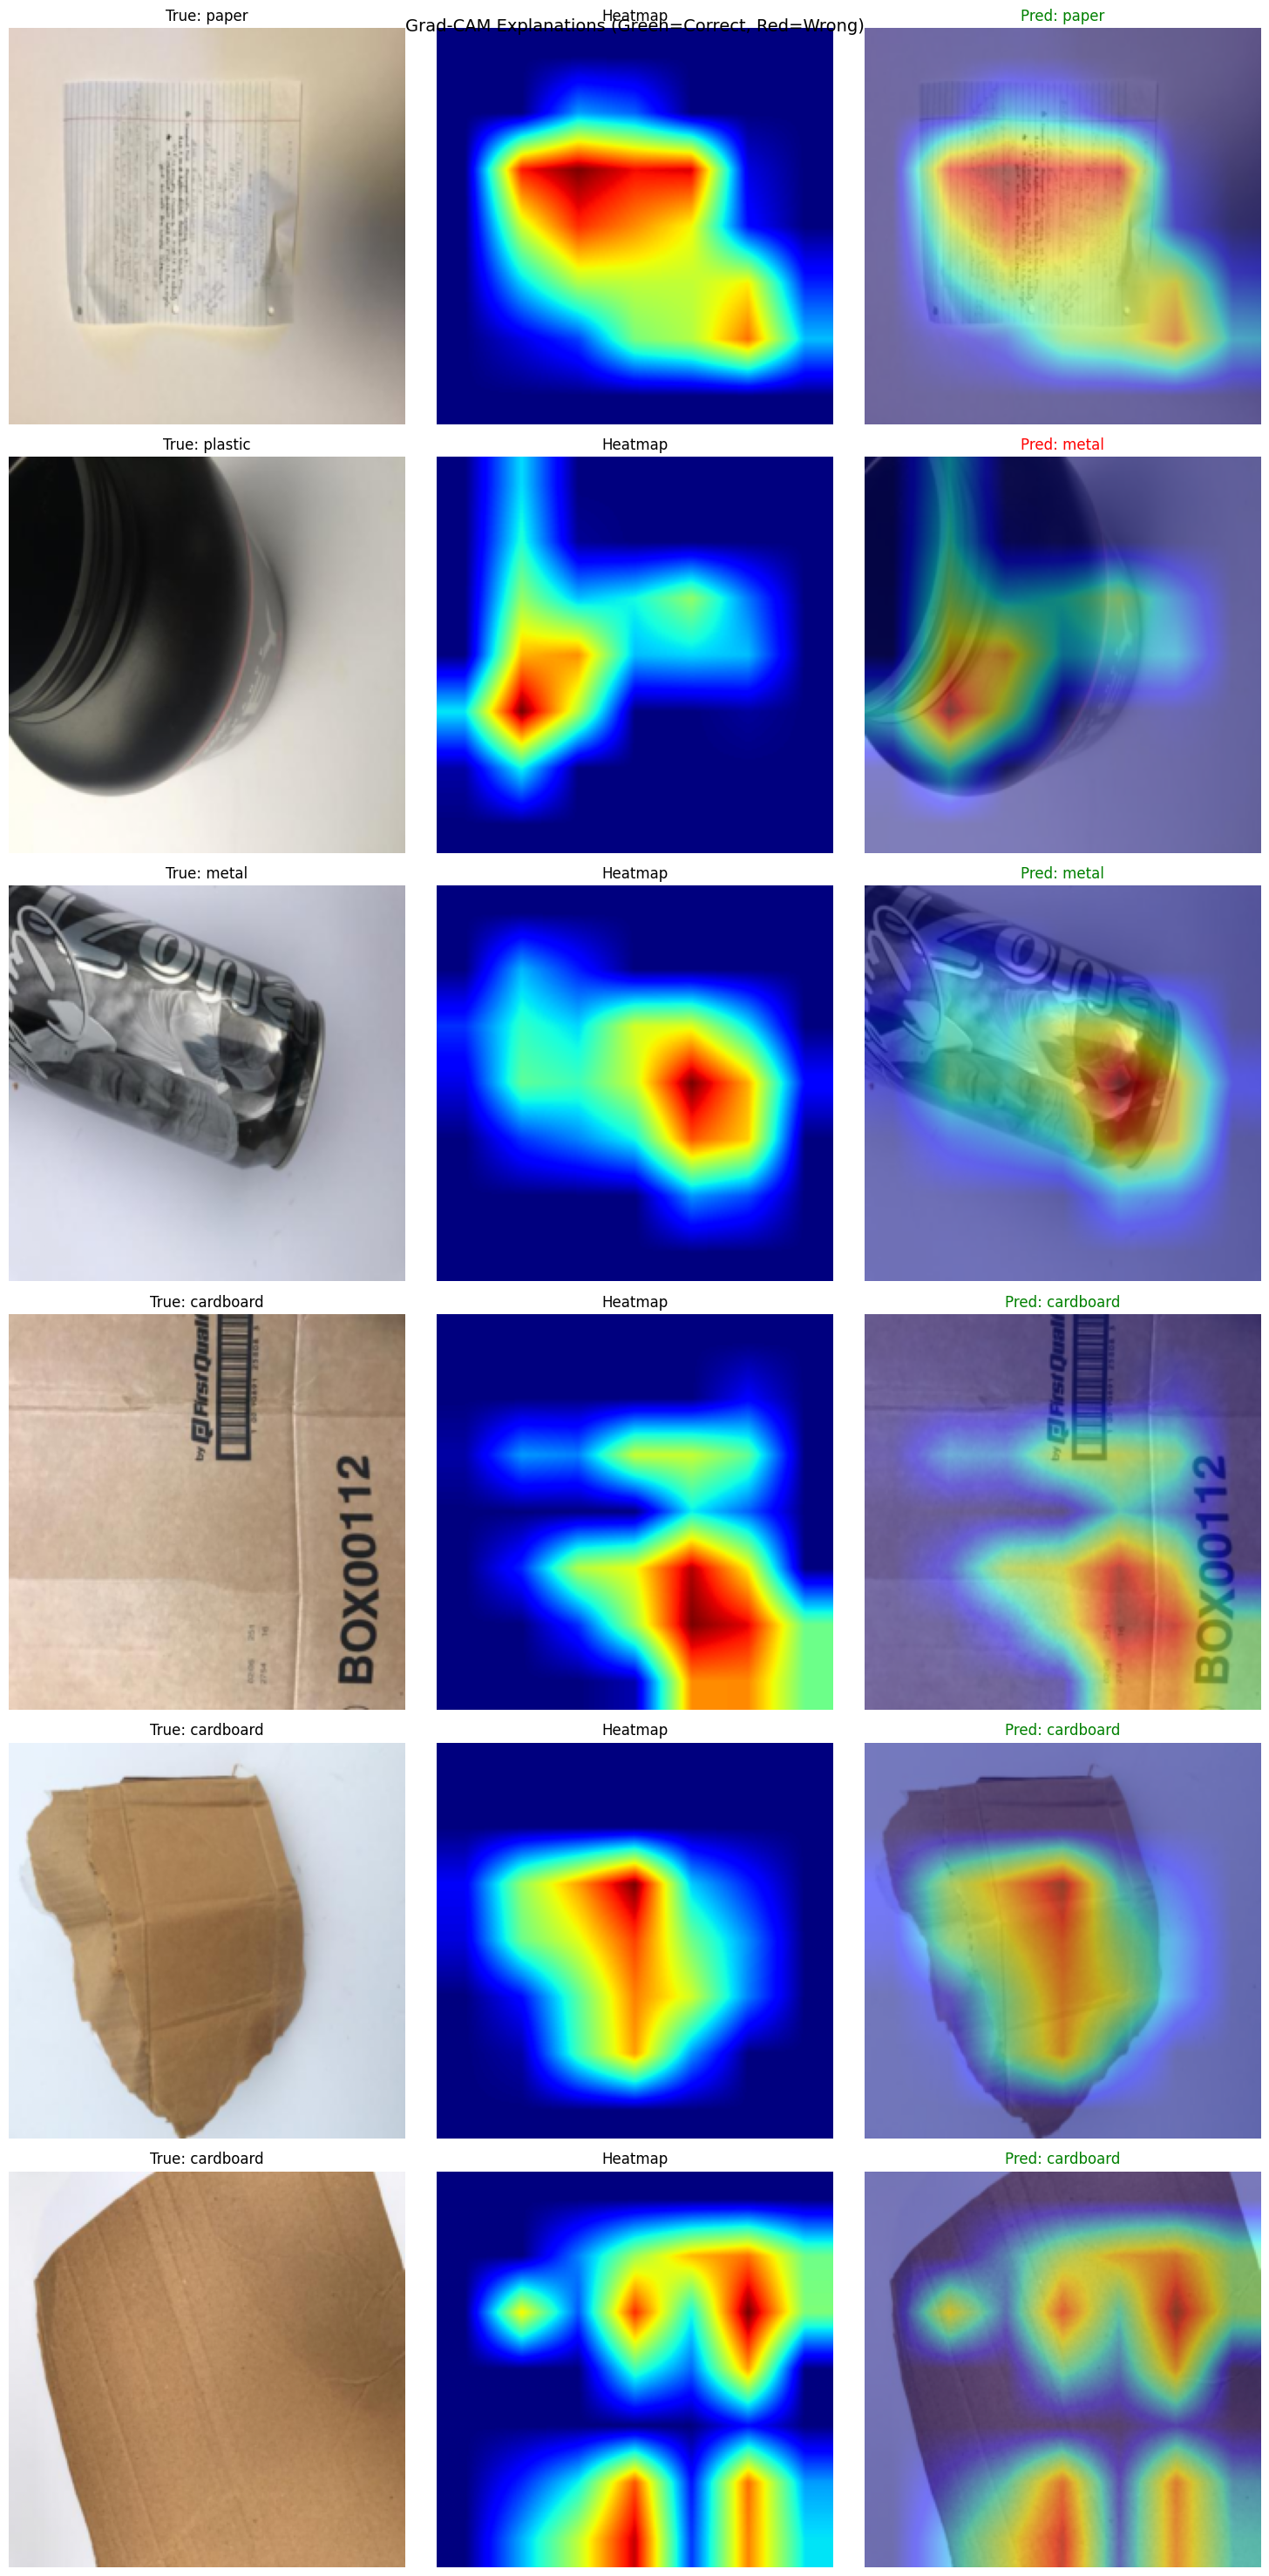

✅ Grad-CAM saved!

🔬 Running Robustness Tests...

  Clean                          Accuracy: 94.74%
  Gaussian Noise (low)           Accuracy: 77.11%
  Gaussian Noise (med)           Accuracy: 70.26%
  Gaussian Noise (high)          Accuracy: 46.84%
  Blur (r=1)                     Accuracy: 46.84%
  Blur (r=3)                     Accuracy: 29.47%
  Blur (r=5)                     Accuracy: 25.53%
  Bright (1.5x)                  Accuracy: 70.00%
  Bright (2.5x)                  Accuracy: 61.05%
  Dark (0.5x)                    Accuracy: 81.32%
  Dark (0.2x)                    Accuracy: 79.74%
  Salt & Pepper (5%)             Accuracy: 54.74%
  Salt & Pepper (15%)            Accuracy: 37.11%


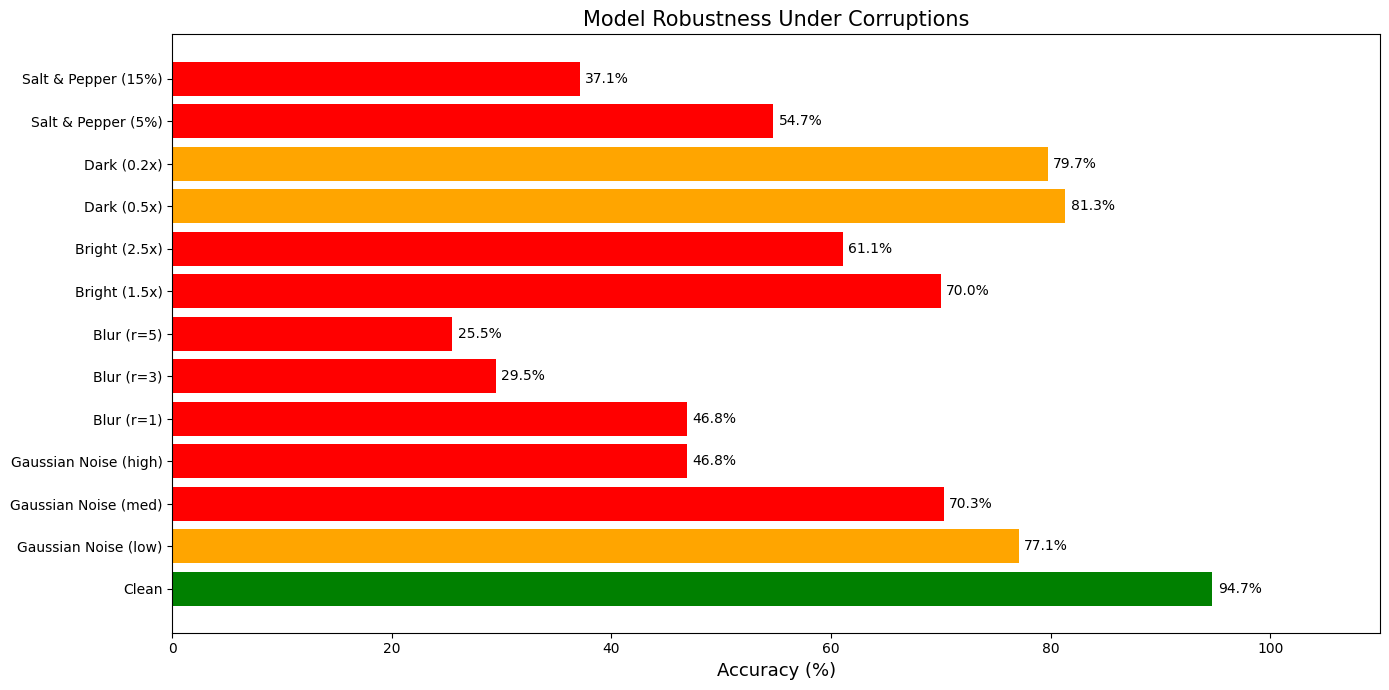


🎉 ALL DONE!
   Best Val Accuracy : 93.93%
   Saved Files       : training_curve.png | gradcam_results.png | robustness_results.png | best_model.pth


In [1]:
# ============================================================
# 🗑️ WASTE CLASSIFICATION - COMPLETE PIPELINE (Single Cell)
# ============================================================

# ==================== INSTALL ====================
import subprocess
subprocess.run(["pip", "install", "-q", "torch", "torchvision", "scikit-learn", "matplotlib", "Pillow"])

# ==================== IMPORTS ====================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image, ImageFilter

# ==================== SEED ====================
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# ==================== DOWNLOAD DATASET ====================
import zipfile, urllib.request

os.makedirs("data/raw", exist_ok=True)

if not os.path.exists("data/raw/trashnet"):
    print("📥 Downloading TrashNet dataset...")
    url = "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip"
    urllib.request.urlretrieve(url, "dataset.zip")
    with zipfile.ZipFile("dataset.zip", "r") as z:
        z.extractall("data/raw/")
    os.rename("data/raw/dataset-resized", "data/raw/trashnet")
    print("✅ Dataset downloaded and extracted!")
else:
    print("✅ Dataset already exists!")

data_dir = "data/raw/trashnet"

# ==================== DATASET ====================
def get_dataloaders(data_dir, batch_size=32):
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
    total        = len(full_dataset)
    train_size   = int(0.70 * total)
    val_size     = int(0.15 * total)
    test_size    = total - train_size - val_size

    train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])
    val_set.dataset  = datasets.ImageFolder(data_dir, transform=val_test_transform)
    test_set.dataset = datasets.ImageFolder(data_dir, transform=val_test_transform)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f"✅ Dataset: {total} images | {len(full_dataset.classes)} classes: {full_dataset.classes}")
    print(f"   Train: {train_size} | Val: {val_size} | Test: {test_size}")
    return train_loader, val_loader, test_loader, full_dataset.classes

train_loader, val_loader, test_loader, classes = get_dataloaders(data_dir)

# ==================== MODEL ====================
class WasteClassifier(nn.Module):
    def __init__(self, num_classes):
        super(WasteClassifier, self).__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for name, param in self.backbone.named_parameters():
            if "layer3" in name or "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = WasteClassifier(num_classes=len(classes)).to(device)

# ==================== TRAIN ====================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs    = 30
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

os.makedirs("models/saved_models", exist_ok=True)
save_path      = "models/saved_models/best_model.pth"
best_val_acc   = 0.0
patience       = 7
no_improve     = 0

train_acc_list = []
val_acc_list   = []

print("\n🚀 Starting Training...\n")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_acc = 100.0 * correct / total
    scheduler.step()

    model.eval()
    val_correct = 0
    val_total   = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_acc    = 100.0 * val_correct / val_total
    current_lr = scheduler.get_last_lr()[0]

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {total_loss:.4f} | "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | LR: {current_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), save_path)
        print(f"   🏆 Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

print(f"\n✅ Training Done! Best Val Accuracy: {best_val_acc:.2f}%")

# ✅ Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_acc_list, label="Train Acc", marker="o")
plt.plot(val_acc_list,   label="Val Acc",   marker="s")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

# ==================== EVALUATE ====================
print("\n📊 Evaluating on Test Set...\n")
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Recall:    {recall_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print("\n📋 Per-Class Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# ==================== GRAD-CAM (EXPLAIN) ====================
print("\n🔍 Running Grad-CAM Explanations...\n")

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor):
        self.model.eval()
        output    = self.model(input_tensor)
        class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot   = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam    -= cam.min()
        cam    /= cam.max() + 1e-8
        return cam, class_idx

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.squeeze() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

target_layer = model.backbone.layer4[-1].conv3
grad_cam     = GradCAM(model, target_layer)

num_images = 6
fig, axes  = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
shown      = 0

for images, labels in test_loader:
    for i in range(images.size(0)):
        if shown >= num_images:
            break
        input_tensor = images[i].unsqueeze(0).to(device)
        cam, pred_idx = grad_cam.generate(input_tensor)
        img_np   = denormalize(images[i])
        heatmap  = cm.jet(cam)[:, :, :3]
        overlay  = 0.5 * img_np + 0.5 * heatmap
        true_lbl = classes[labels[i].item()]
        pred_lbl = classes[pred_idx]
        color    = "green" if true_lbl == pred_lbl else "red"
        axes[shown][0].imshow(img_np);      axes[shown][0].set_title(f"True: {true_lbl}");         axes[shown][0].axis("off")
        axes[shown][1].imshow(cam, cmap="jet"); axes[shown][1].set_title("Heatmap");               axes[shown][1].axis("off")
        axes[shown][2].imshow(overlay);     axes[shown][2].set_title(f"Pred: {pred_lbl}", color=color); axes[shown][2].axis("off")
        shown += 1
    if shown >= num_images:
        break

plt.suptitle("Grad-CAM Explanations (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.savefig("gradcam_results.png", dpi=150)
plt.show()
print("✅ Grad-CAM saved!")

# ==================== ROBUSTNESS ====================
print("\n🔬 Running Robustness Tests...\n")

def add_gaussian_noise(imgs, s=0.15):  return (imgs + torch.randn_like(imgs) * s).clamp(0, 1)
def add_brightness(imgs, f=1.5):       return (imgs * f).clamp(0, 1)
def add_darkness(imgs, f=0.3):         return (imgs * f).clamp(0, 1)
def add_salt_pepper(imgs, amt=0.05):
    out = imgs.clone()
    n   = int(amt * imgs.shape[2] * imgs.shape[3])
    for i in range(imgs.shape[0]):
        y, x = torch.randint(0, imgs.shape[2], (n,)), torch.randint(0, imgs.shape[3], (n,))
        out[i, :, y, x] = 1.0
        y, x = torch.randint(0, imgs.shape[2], (n,)), torch.randint(0, imgs.shape[3], (n,))
        out[i, :, y, x] = 0.0
    return out
def add_blur(imgs, radius=3):
    blurred = []
    for img in imgs:
        pil = transforms.ToPILImage()(img.cpu())
        pil = pil.filter(ImageFilter.GaussianBlur(radius=radius))
        blurred.append(transforms.ToTensor()(pil))
    return torch.stack(blurred).to(imgs.device)

def eval_corruption(model, loader, fn, name):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            imgs = fn(imgs)
            _, pred = model(imgs).max(1)
            correct += pred.eq(lbls).sum().item()
            total   += lbls.size(0)
    acc = 100.0 * correct / total
    print(f"  {name:<30} Accuracy: {acc:.2f}%")
    return acc

corruptions = [
    ("Clean",                  lambda x: x),
    ("Gaussian Noise (low)",   lambda x: add_gaussian_noise(x, 0.05)),
    ("Gaussian Noise (med)",   lambda x: add_gaussian_noise(x, 0.15)),
    ("Gaussian Noise (high)",  lambda x: add_gaussian_noise(x, 0.30)),
    ("Blur (r=1)",             lambda x: add_blur(x, 1)),
    ("Blur (r=3)",             lambda x: add_blur(x, 3)),
    ("Blur (r=5)",             lambda x: add_blur(x, 5)),
    ("Bright (1.5x)",          lambda x: add_brightness(x, 1.5)),
    ("Bright (2.5x)",          lambda x: add_brightness(x, 2.5)),
    ("Dark (0.5x)",            lambda x: add_darkness(x, 0.5)),
    ("Dark (0.2x)",            lambda x: add_darkness(x, 0.2)),
    ("Salt & Pepper (5%)",     lambda x: add_salt_pepper(x, 0.05)),
    ("Salt & Pepper (15%)",    lambda x: add_salt_pepper(x, 0.15)),
]

names, accs = [], []
for name, fn in corruptions:
    acc = eval_corruption(model, test_loader, fn, name)
    names.append(name)
    accs.append(acc)

# ✅ Plot robustness
colors = ["green" if a >= 90 else "orange" if a >= 75 else "red" for a in accs]
plt.figure(figsize=(14, 7))
bars = plt.barh(names, accs, color=colors)
plt.xlabel("Accuracy (%)", fontsize=13)
plt.title("Model Robustness Under Corruptions", fontsize=15)
plt.xlim(0, 110)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{acc:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("robustness_results.png", dpi=150)
plt.show()

print("\n🎉 ALL DONE!")
print(f"   Best Val Accuracy : {best_val_acc:.2f}%")
print(f"   Saved Files       : training_curve.png | gradcam_results.png | robustness_results.png | best_model.pth")